In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [22]:
df = pd.read_csv(r"C:\Users\mssha\OneDrive\Desktop\ImpactSense\data\earthquake_week2_processed.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (414, 6)
   magnitude     depth       cdi       mmi       sig  alert
0  -0.374928  0.716094 -0.226867  0.265434 -1.436103      2
1   0.200174 -0.760315  1.392496  0.265434  0.376739      2
2   1.062828  0.716094 -0.226867  0.265434 -0.693493      2
3   0.487726  0.568453 -0.226867  1.813176 -0.780859      2
4  -1.525132 -1.055597  1.392496  0.265434  0.311215      2


In [24]:
X = df.drop("alert", axis=1)
y = df["alert"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [26]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9036144578313253


In [27]:
param_grid = {
    'n_estimators':[200,300,400],
    'max_depth':[10,15,20],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2],
    'max_features':['sqrt','log2']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)

Best Parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}


In [15]:
param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


In [28]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9036144578313253
              precision    recall  f1-score   support

           1       0.93      0.74      0.82        19
           2       0.93      0.98      0.95        52
           3       0.77      0.83      0.80        12

    accuracy                           0.90        83
   macro avg       0.88      0.85      0.86        83
weighted avg       0.91      0.90      0.90        83



In [29]:
gb = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=300,
    max_depth=8,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.9036144578313253


In [30]:
param_grid_gb = {
    'n_estimators':[200,300,400],
    'learning_rate':[0.01,0.05,0.1],
    'max_depth':[5,7,9],
    'min_samples_split':[2,5]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print("Best Parameters:", grid_gb.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 9, 'min_samples_split': 5, 'n_estimators': 200}


In [31]:
best_gb = grid_gb.best_estimator_

y_pred_gb = best_gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.927710843373494
              precision    recall  f1-score   support

           1       0.94      0.79      0.86        19
           2       0.93      0.98      0.95        52
           3       0.92      0.92      0.92        12

    accuracy                           0.93        83
   macro avg       0.93      0.90      0.91        83
weighted avg       0.93      0.93      0.93        83



In [32]:
cv_scores = cross_val_score(best_rf, X, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.91566265 0.90361446 0.81927711 0.85542169 0.91463415]
Average CV Accuracy: 0.8817220099911843


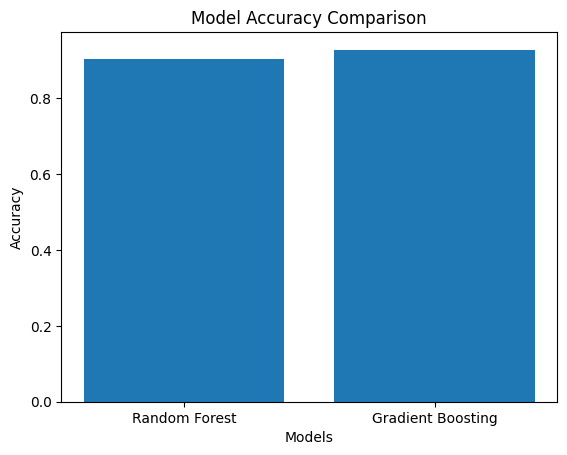

In [33]:
import matplotlib.pyplot as plt

models = ["Random Forest", "Gradient Boosting"]
accuracy = [
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_gb)
]

plt.figure()
plt.bar(models, accuracy)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()